In [1]:
import numpy as np
import matplotlib.pyplot as plt

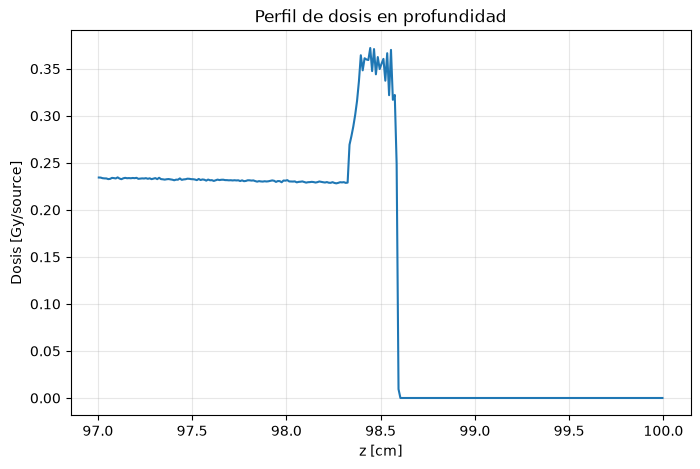

In [3]:
archivo = "../out/bragg_cr.out"

z = []
dosis = []
error = []

leyendo = False

with open(archivo, "r") as f:
    for linea in f:
        if "#  z-lower" in linea and "proton" in linea:
            leyendo = True
            continue

        if leyendo:
            if linea.startswith("#") or linea.startswith("'"):
                break

            partes = linea.split()

            if len(partes) == 4:
                try:
                    z_lower = float(partes[0])
                    z_upper = float(partes[1])
                    dose = float(partes[2])
                    rerr = float(partes[3])

                    z.append((z_lower + z_upper) / 2)
                    dosis.append(dose)
                    error.append(dose * rerr)

                except ValueError:
                    pass

z = np.array(z)
dosis = np.array(dosis)
error = np.array(error)

plt.figure(figsize=(8,5))
plt.plot(z, dosis)
plt.xlabel("z [cm]")
plt.ylabel("Dosis [Gy/source]")
plt.title("Perfil de dosis en profundidad")
plt.grid(alpha=0.3)
plt.show()

Seria el pico de bragg ahi:

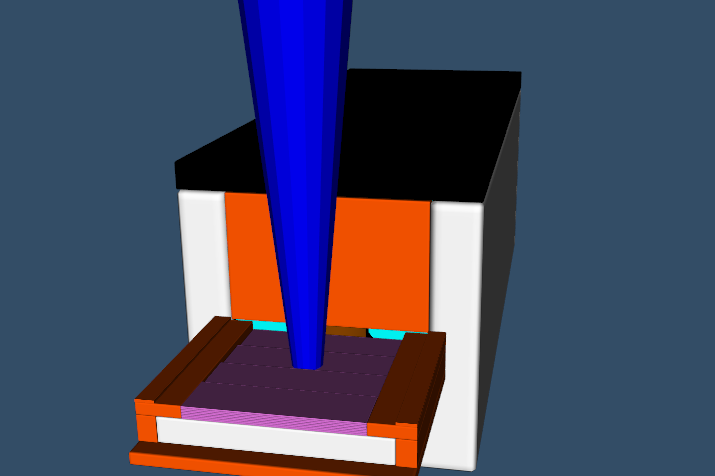